<a href="https://colab.research.google.com/github/quocthai2007/Test-Base-Pipeline-AIC26/blob/main/HCMAI2025_Pipeline_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HCMC AI Challenge 2025 - AHT Notebook

Day la notebook thực hiện baseline trich xuat Keyframe va Tim kiem Vector danh cho cuoc thi HCMC AI Challenge 2025.

### Tong quan bai toan
Bai toan yeu cau chung ta tim kiem cac phan doan (moments) trong mot kho du lieu video lon (Video Corpus) dua tren cac cau truy van dang van ban (Textual Query) hoac hinh anh (Visual Query).

### Thiet ke Pipeline (Image-Level Approach)
Thay vi su dung cac mo hinh Video-Level yeu cau tai nguyen lon va bo nho luu tru hang tram GB, pipeline nay thuc hien phuong phap Image-Level toi uu hon:
1. Shot Boundary Detection (SBD): Su dung mo hinh TransNetV2 de chia nho video thanh cac phan doan canh (scenes/shots).
2. Keyframe Selection va CLIP Filtering:
   - Lay ra 4 frame dai dien cho moi scene (Start, 1/3, 2/3, End).
   - Su dung CLIP (hoac OpenCLIP) de tinh visual embeddings cho cac frame nay.
   - Loc trung lap bang cach tinh Cosine Similarity giua cac frame lien tiep trong cung mot scene. Neu similarity vuot qua nguong threshold (vi du 0.8), ta loai bo frame trung lap de tiet kiem dung luong luu tru.
3. Indexing va Vector Search:
   - Luu tru cac keyframe va nap embeddings cua chung vao FAISS (IndexFlatIP) de phuc vu tim kiem voi do tre thap.
   - Ho tro query bang Text (Text-to-Image) va Image (Image-to-Image) theo dung thiet ke cua search.ipynb.
4. Adaptive Temporal Search va Reranking (Advanced):
   - Huong dan ap dung thuat toan Adaptive Temporal Search (Exploration vs Exploitation) va Reranking de cai thien ket qua.

In [ ]:
# Cai dat cac thu vien can thiet
!pip install -q transnetv2-pytorch==1.0.5 ffmpeg-python open_clip_torch faiss-cpu

## Tai Du Lieu va Chuan bi Moi Truong
Du lieu cua cuoc thi rat lon. Su dung Kaggle API de tai truc tiep tu Kaggle ve Colab/Kaggle Notebook.

### Su dung Kaggle API tren Colab:
1. Truy cap vao tai khoan Kaggle -> Settings -> Click Create New Token  tai file kaggle.json.
2. Chay cell code de upload file kaggle.json len Colab.


In [ ]:
# from google.colab import files
# import os

# # Upload file kaggle.json
# if not os.path.exists('/root/.kaggle/kaggle.json'):
#     print("Upload file kaggle.json tu may tinh:")
#     uploaded = files.upload()
#     for fn in uploaded.keys():
#         print('Da upload file "{name}" voi kich thuoc {length} bytes'.format(
#             name=fn, length=len(uploaded[fn])))

#     !mkdir -p ~/.kaggle
#     !mv kaggle.json ~/.kaggle/
#     !chmod 600 ~/.kaggle/kaggle.json
#     print("Cau hinh Kaggle API thanh cong!")
# else:
#     print("File kaggle.json da ton tai!")

### Tai Weights cua TransNetV2 va Video Demo
Tai file weights transnetv2-pytorch-weights.pth va mot video demo de chay thu nghiem pipeline.

In [ ]:
import os
import gdown
import shutil

os.makedirs("weights", exist_ok=True)
os.makedirs("data", exist_ok=True)

transnet_weights_path = "weights/transnetv2-pytorch-weights.pth"
local_ref_path = "ref25/part1/code/transnetv2-pytorch-weights.pth"

if not os.path.exists(transnet_weights_path):
    # 1. Thu copy tu thu muc ref25 neu chay local
    if os.path.exists(local_ref_path):
        print("Phat hien file weights cuc bo tai ref25. Dang copy...")
        shutil.copy(local_ref_path, transnet_weights_path)
        print("[OK] Copy file weights thanh cong!")
    else:
        # 2. Tai tu guong Hugging Face vao Colab/Kaggle de tranh loi quota Google Drive
        print("Dang tai weights TransNetV2 tu Hugging Face...")
        url = "https://huggingface.co/MiaoshouAI/transnetv2-pytorch-weights/resolve/main/transnetv2-pytorch-weights.pth"
        os.system(f"wget -q -O {transnet_weights_path} {url}")

        # Kiem tra xem file tai ve co dung chuan va kich thuoc hop le (> 10MB)
        if os.path.exists(transnet_weights_path) and os.path.getsize(transnet_weights_path) > 10000000:
            print("[OK] Tai weights tu Hugging Face thanh cong!")
        else:
            # 3. Su dung gdown lam fallback cuoi cung
            print("[CANH BAO] Tai tu Hugging Face that bai. Dang thu download tu Google Drive...")
            gdown.download(id="1K7tpO6NMGVqCF30mwuyR-i2HZMA7Fsrg", output=transnet_weights_path, quiet=False)
            print("[OK] Hoan thanh tai tu Google Drive!")
else:
    print("[OK] Weights TransNetV2 da san sang!")

# Tai video demo
video_path = "data/demo_video.mp4"
if not os.path.exists(video_path):
    print("Dang tai video demo...")
    gdown.download(id="1DoAkeqvRtvThY7wnCN01LGLi8wsE_U_I", output=video_path, quiet=False)
    print("[OK] Tai video demo thanh cong!")
else:
    print("[OK] Video demo da ton tai tai:", video_path)

[OK] Weights TransNetV2 da san sang!
[OK] Video demo da ton tai tai: data/demo_video.mp4


### Clone repository TransNetV2 chinh thuc de su dung code

In [ ]:
if not os.path.exists('TransNetV2'):
    !git clone https://github.com/soCzech/TransNetV2.git
    print("[OK] Da clone repo TransNetV2!")
else:
    print("[OK] Repo TransNetV2 da ton tai!")

[OK] Repo TransNetV2 da ton tai!


## 1. Shot Boundary Detection (Phat hien Cat canh)


In [ ]:
import numpy as np
import ffmpeg
import torch
from transnetv2_pytorch import TransNetV2

INPUT_WIDTH = 48
INPUT_HEIGHT = 27

def load_video_lowres(v_path):
    print(f"Dang doc video va resize ve {INPUT_WIDTH}x{INPUT_HEIGHT} bang FFmpeg...")
    try:
        video_stream, err = (
            ffmpeg.input(v_path)
            .output("pipe:", format="rawvideo", pix_fmt="rgb24", s=f"{INPUT_WIDTH}x{INPUT_HEIGHT}")
            .run(capture_stdout=True, capture_stderr=True)
        )
        video_np = np.frombuffer(video_stream, np.uint8).reshape([-1, INPUT_HEIGHT, INPUT_WIDTH, 3])
        print(f"[OK] Doc video thanh cong! Tong so frames: {video_np.shape[0]}")
        return video_np
    except Exception as e:
        print("[LOI] Loi khi doc video:", e)
        return None

video_frames = load_video_lowres(video_path)

Dang doc video va resize ve 48x27 bang FFmpeg...
[OK] Doc video thanh cong! Tong so frames: 4113


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Chay tren thiet bi: {device}")

model = TransNetV2()
if os.path.exists(transnet_weights_path):
    # Set weights_only=False de tranh loi unpickling tren PyTorch 2.6+
    state_dict = torch.load(transnet_weights_path, map_location=device, weights_only=False)
    model.load_state_dict(state_dict)
    print("[OK] Da load weights TransNetV2 thanh cong!")
else:
    print("[LOI] Khong tim thay weights TransNetV2.")

model.eval()
if device == "cuda":
    model = model.cuda()

if video_frames is not None:
    with torch.no_grad():
        video_torch = torch.from_numpy(video_frames)
        if device == "cuda":
            video_torch = video_torch.cuda()
        single_frame_pred, all_frame_pred = model(video_torch.unsqueeze(0))

        single_frame_pred = torch.sigmoid(single_frame_pred).cpu().numpy().squeeze()
        all_frame_pred = torch.sigmoid(all_frame_pred["many_hot"]).cpu().numpy().squeeze()

    print(f"[OK] Da du doan xong! Kich thuoc mang ket qua: {single_frame_pred.shape}")

Chay tren thiet bi: cuda
[OK] Da load weights TransNetV2 thanh cong!


/tmp/ipykernel_5954/4243749707.py:19: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  video_torch = torch.from_numpy(video_frames)


[OK] Da du doan xong! Kich thuoc mang ket qua: (4113,)


### Phan tich Canh (Scenes)
Tu ket qua du doan cua TransNetV2, chung ta se nhom cac frame lien tiep thanh cac canh (scenes) dua tren cac diem cat (cuts).

In [ ]:
def pick_cut_indices(prob, thr=0.5, min_cut_distance=12):
    """
    Chuyen xac suat boundary cua tung frame thanh cac chi so diem cat (cuts).
    - thr: Nguong xac suat de coi la diem cat.
    - min_cut_distance: So luong frame toi thieu giua 2 diem cat de tranh trung lap.
    """
    p = np.asarray(prob, dtype=float).reshape(-1)
    N = p.shape[0]
    mask = p >= thr

    cuts = []
    i = 0
    while i < N:
        if mask[i]:
            j = i
            while j + 1 < N and mask[j + 1]:
                j += 1
            idx = i + int(np.argmax(p[i:j+1]))
            cuts.append(idx)
            i = j + 1
        else:
            i += 1

    pruned = []
    for idx in cuts:
        if not pruned or idx - pruned[-1] >= min_cut_distance:
            pruned.append(idx)
        else:
            if p[idx] > p[pruned[-1]]:
                pruned[-1] = idx
    return pruned

def cuts_to_scenes(cuts, n_frames):
    """Chuyen doi danh sach cac diem cat thanh cac doan [start, end] inclusive scenes."""
    cuts = sorted(int(c) for c in cuts if 0 <= c < n_frames)
    starts = [0] + [c + 1 for c in cuts]
    ends   = cuts + [n_frames - 1]
    return list(zip(starts, ends))

def sample_scene_four(s, e):
    """Lay ra 4 frame dai dien: bat dau, 2 frame giua, va ket thuc."""
    return np.linspace(s, e, num=4, dtype=int).tolist()

# Trich xuat cac diem cat va phan doan scenes
cut_indices = pick_cut_indices(single_frame_pred, thr=0.5, min_cut_distance=12)
scenes = cuts_to_scenes(cut_indices, n_frames=video_frames.shape[0])
print(f"Tim thay {len(cut_indices)} diem cat.")
print(f"Tong so scenes phan doan duoc: {len(scenes)}")

Tim thay 10 diem cat.
Tong so scenes phan doan duoc: 11


## 2. Keyframe Selection va CLIP Loc trung lap
Thuc hien dung thuat toan loc keyframe trong selection.ipynb bang cach dung OpenCLIP va cosine similarity de loai bo cac frame qua giong nhau trong cung mot scene.

In [ ]:
import open_clip
from PIL import Image

print("Dang khoi tao OpenCLIP ViT-B-32...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k', device=device
)
clip_model.eval()
print("[OK] Khoi tao OpenCLIP thanh cong!")

Dang khoi tao OpenCLIP ViT-B-32...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

[OK] Khoi tao OpenCLIP thanh cong!


In [ ]:
def _prep_frames_for_clip(frames_uint8, preprocess):
    """
    frames_uint8 : (B, H, W, 3) uint8 in RGB
    tra ve float tensor (B, 3, 224, 224) duoc preprocess cho model
    """
    pil_list = [Image.fromarray(fr) for fr in frames_uint8]
    tensors  = [preprocess(img) for img in pil_list]
    return torch.stack(tensors, dim=0)

@torch.no_grad()
def compute_clip_embeddings(frames_uint8: np.ndarray,
                            indices: np.ndarray,
                            device: str = "cuda",
                            model_name: str = "ViT-B-32",
                            pretrained: str = "laion2b_s34b_b79k",
                            batch_size: int = 64) -> dict:
    """
    Tinh embedding CLIP da duoc L2 normalized cho cac frame duoc chon.
    """
    idx = np.unique(indices.astype(int))
    out = {}
    for start in range(0, len(idx), batch_size):
        chunk_idx = idx[start:start+batch_size]
        batch = _prep_frames_for_clip(frames_uint8[chunk_idx], clip_preprocess).to(device)
        feats = clip_model.encode_image(batch)
        feats = feats / feats.norm(dim=-1, keepdim=True)  # L2-normalize
        for i, fi in zip(chunk_idx, feats):
            out[int(i)] = fi.detach().cpu().numpy()
    return out

def filter_selected_frames_with_clip(
    frames_uint8: np.ndarray,
    selected_idx_per_scene: list[list[int]],
    threshold: float = 0.8,
    device: str = "cuda",
    model_name: str = "ViT-B-32",
    pretrained: str = "laion2b_s34b_b79k",
    batch_size: int = 64,
    mode: str = "any",
):
    """
    Loai bo frame trong scene neu no qua giong voi 1-2 frame truoc do.
    """
    all_indices = np.array([i for scene in selected_idx_per_scene for i in scene], dtype=int)
    emb_map = compute_clip_embeddings(
        frames_uint8, all_indices, device=device,
        model_name=model_name, pretrained=pretrained, batch_size=batch_size
    )

    def cos(a, b):
        return float(np.dot(a, b))

    kept, dropped = [], []
    for scene in selected_idx_per_scene:
        scene = list(scene)
        if len(scene) == 0:
            kept.append([])
            dropped.append([])
            continue

        kept_this = [scene[0]]
        dropped_this = []

        start_t = 1
        if len(scene) >= 2:
            t = 1
            s1 = cos(emb_map[scene[t]], emb_map[scene[t-1]])
            drop = (s1 >= threshold)
            if not drop:
                kept_this.append(scene[t])
            else:
                dropped_this.append(scene[t])
            start_t = 2

        for t in range(start_t, len(scene)):
            s1 = cos(emb_map[scene[t]], emb_map[scene[t-1]])
            s2 = cos(emb_map[scene[t]], emb_map[scene[t-2]])

            if mode == "all":
                drop = (s1 >= threshold) and (s2 >= threshold)
            else:
                drop = (s1 >= threshold) or (s2 >= threshold)

            if drop:
                dropped_this.append(scene[t])
            else:
                kept_this.append(scene[t])

        kept.append(kept_this)
        dropped.append(dropped_this)

    return kept, dropped, emb_map

In [ ]:
# Thuc thi loc keyframe
selected_idx_per_scene = [sample_scene_four(s, e) for (s, e) in scenes]
kept, dropped, emb_map = filter_selected_frames_with_clip(
    video_frames.astype(np.uint8),
    selected_idx_per_scene,
    threshold=0.8,
    device=device,
    model_name="ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)

# Flatten danh sach cac keyframe da duoc giu lai
kept_indices = sorted([idx for scene in kept for idx in scene])
print(f"Giup giam so luong keyframe. Ban dau: {len(scenes)*4}, Sau khi loc: {len(kept_indices)}")

Giup giam so luong keyframe. Ban dau: 44, Sau khi loc: 18


### Luu tru Keyframes va Threshold-based Keyframes
Notebook thuc hien ca 2 phuong phap chon keyframe theo dung huong dan cua search.ipynb:
1. Method 1: Chon theo Scene-based keyframes (kept_indices).
2. Method 2: Chon truc tiep theo nguong threshold (frames_above_threshold).

In [ ]:
import cv2
from pathlib import Path
from typing import Iterable, Tuple, List

# 1. Save scene-based keyframes (begin, middle, end) vao scenes_by_threshold
def save_scene_keyframes_from_preds(
    frames: np.ndarray,
    predictions: Iterable[np.ndarray] | np.ndarray,
    threshold: float = 0.5,
    min_scene_len: int = 6,
    root_dir: str = "scenes_by_threshold",
    image_quality: int = 95,
) -> List[Tuple[int, int, int]]:
    if isinstance(predictions, np.ndarray):
        predictions = [predictions]
    pred_mat = np.vstack([np.squeeze(p).astype(np.float32) for p in predictions])
    cut_bool = (pred_mat > threshold).any(axis=0)
    cut_indices = np.where(~cut_bool[:-1] & cut_bool[1:])[0] + 1

    scenes = []
    start = 0
    for cut in cut_indices:
        if cut - start >= min_scene_len:
            scenes.append((start, cut - 1))
        start = cut
    scenes.append((start, frames.shape[0] - 1))

    Path(root_dir).mkdir(parents=True, exist_ok=True)
    keyframes = []
    for i, (s_idx, e_idx) in enumerate(scenes, start=1):
        m_idx = (s_idx + e_idx) // 2
        if e_idx - s_idx + 1 < min_scene_len:
            continue
        keyframes.append((s_idx, m_idx, e_idx))
        scene_dir = Path(root_dir) / f"scene_{i:04d}"
        scene_dir.mkdir(exist_ok=True)
        for idx, name in zip((s_idx, m_idx, e_idx), ("begin.jpg", "middle.jpg", "end.jpg")):
            Image.fromarray(frames[idx]).save(scene_dir / name, quality=image_quality)
    return keyframes

# 2. Save threshold-based keyframes (frames co score > threshold) vao FRAME_DIR
def frames_above_threshold(
    frames: np.ndarray,
    predictions: Iterable[np.ndarray] | np.ndarray,
    threshold: float = 0.5,
    save_dir: str | None = None
) -> Tuple[List[np.ndarray], np.ndarray]:
    if isinstance(predictions, np.ndarray):
        predictions = [predictions]
    pred_mat = np.vstack([np.squeeze(p) for p in predictions]).astype(np.float32)
    idxs = np.where((pred_mat > threshold).any(axis=0))[0]
    selected_frames = [frames[i] for i in idxs]
    if save_dir is not None:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
        for i, f in zip(idxs, selected_frames):
            Image.fromarray(f).save(save_path / f"frame_{i:06d}.jpg", quality=95)
    return selected_frames, idxs

# Thuc thi luu tru ca hai phuong phap
print("Dang luu tru keyframes...")
scenes_keyframes = save_scene_keyframes_from_preds(
    frames=video_frames.astype(np.uint8),
    predictions=(single_frame_pred, all_frame_pred),
    threshold=0.6,
    min_scene_len=6,
    root_dir="scenes_by_threshold"
)

FRAME_DIR = "vo_dich_HCMAI"
threshold_frames, threshold_indices = frames_above_threshold(
    frames=video_frames.astype(np.uint8),
    predictions=(single_frame_pred, all_frame_pred),
    threshold=0.6,
    save_dir=FRAME_DIR
)
print(f"[OK] Luu tru thanh cong. Scene-based: {len(scenes_keyframes)} scenes, Threshold-based: {len(threshold_indices)} frames.")

Dang luu tru keyframes...
[OK] Luu tru thanh cong. Scene-based: 16 scenes, Threshold-based: 90 frames.


## 3. Xay dung Vector Index va Tim kiem voi FAISS
Xay dung he thong tim kiem voi FAISS va OpenCLIP dung nhu logic trong search.ipynb.

In [ ]:
import faiss
import glob
import re
import pathlib

def load_image_for_clip(path, preprocess):
    img = Image.open(path).convert("RGB")
    return preprocess(img).unsqueeze(0)

def gather_dataset(root="scenes_by_threshold"):
    paths, scene_ids, tags = [], [], []
    for scene_dir in sorted(pathlib.Path(root).glob("scene_*")):
        sid = scene_dir.name
        for fn in ["begin.jpg", "middle.jpg", "end.jpg"]:
            full = scene_dir / fn
            if full.exists():
                paths.append(str(full))
                scene_ids.append(sid)
                tags.append(fn[:-4])
    return paths, scene_ids, tags

def numeric_key(fp):
    m = re.search(r"(\d+)\D*$", fp)
    return int(m.group(1)) if m else -1

# Thu thap du lieu anh cho ca 2 phuong phap
img_paths, scene_ids, tags = gather_dataset("scenes_by_threshold")
threshold_img_paths = sorted(glob.glob(os.path.join(FRAME_DIR, "*.jpg")), key=numeric_key)

# Tinh embeddings va them vao index
embeds = []
with torch.no_grad():
    for p in img_paths:
        tensor = load_image_for_clip(p, clip_preprocess).to(device)
        feat = clip_model.encode_image(tensor)
        feat /= feat.norm(dim=-1, keepdim=True)
        embeds.append(feat.cpu().numpy())
embeds = np.vstack(embeds).astype("float32")

threshold_embeds = []
with torch.no_grad():
    for p in threshold_img_paths:
        tensor = load_image_for_clip(p, clip_preprocess).to(device)
        feat = clip_model.encode_image(tensor)
        feat /= feat.norm(dim=-1, keepdim=True)
        threshold_embeds.append(feat.cpu().numpy())
threshold_embeds = np.vstack(threshold_embeds).astype("float32")

# Indexing bang FAISS
index = faiss.IndexFlatIP(embeds.shape[1])
index.add(embeds)
print(f"[OK] Indexed {index.ntotal} scene key-frames")

threshold_index = faiss.IndexFlatIP(threshold_embeds.shape[1])
threshold_index.add(threshold_embeds)
print(f"[OK] Indexed {threshold_index.ntotal} threshold key-frames")

[OK] Indexed 48 scene key-frames
[OK] Indexed 90 threshold key-frames


In [ ]:
# Dinh nghia cac ham query va display ket qua search giong search.ipynb
import matplotlib.pyplot as plt

def query_by_image(path, topk=5):
    tensor = load_image_for_clip(path, clip_preprocess).to(device)
    with torch.no_grad():
        q = clip_model.encode_image(tensor)
    q /= q.norm(dim=-1, keepdim=True)
    D, I = index.search(q.cpu().numpy(), topk)
    return I[0], D[0]

def query_by_text(text, topk=5):
    tok = open_clip.tokenize([text]).to(device)
    with torch.no_grad():
        q = clip_model.encode_text(tok)
    q /= q.norm(dim=-1, keepdim=True)
    D, I = index.search(q.cpu().numpy(), topk)
    return I[0], D[0]

def threshold_query_by_image(path, top_k=5):
    tensor = load_image_for_clip(path, clip_preprocess).to(device)
    with torch.no_grad():
        q = clip_model.encode_image(tensor)
    q /= q.norm(dim=-1, keepdim=True)
    D, I = threshold_index.search(q.cpu().numpy(), top_k)
    return I[0], D[0]

def threshold_query_by_text(text, top_k=5):
    tok = open_clip.tokenize([text]).to(device)
    with torch.no_grad():
        q = clip_model.encode_text(tok)
    q /= q.norm(dim=-1, keepdim=True)
    D, I = threshold_index.search(q.cpu().numpy(), top_k)
    return I[0], D[0]

def show_results(indices, scores, query_img=None, query_text=None):
    k = len(indices)
    plt.figure(figsize=(3*(k+1), 4))
    plt.subplot(1, k+1, 1)
    if query_img is not None:
        img = Image.open(query_img)
        resized_img = img.resize((224, 224))
        plt.imshow(resized_img)
        title = "query (image)"
    else:
        plt.text(0.5, 0.5, f"'{query_text}'", ha='center', va='center', wrap=True)
        title = "query (text)"
    plt.title(title)
    plt.axis("off")
    for n, (idx, score) in enumerate(zip(indices, scores), start=2):
        plt.subplot(1, k+1, n)
        img = Image.open(img_paths[idx])
        resized_img = img.resize((224, 224))
        plt.imshow(resized_img)
        lbl = f"{scene_ids[idx]}\nscore: {score:.4f}"
        plt.title(lbl)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def threshold_show_results(indices, scores, query_img=None, query_text=None):
    k = len(indices)
    plt.figure(figsize=(3*(k+1), 4))
    plt.subplot(1, k+1, 1)
    if query_img is not None:
        img = Image.open(query_img)
        resized_img = img.resize((224, 224))
        plt.imshow(resized_img)
        title = "query (image)"
    else:
        plt.text(0.5, 0.5, f"'{query_text}'", ha='center', va='center', wrap=True)
        title = "query (text)"
    plt.title(title)
    plt.axis("off")
    for n, (idx, score) in enumerate(zip(indices, scores), start=2):
        plt.subplot(1, k+1, n)
        img = Image.open(threshold_img_paths[idx])
        resized_img = img.resize((224, 224))
        plt.imshow(resized_img)
        plt.title(f"score: {score:.4f}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

### Chay thu nghiem tim kiem

=== Scene-based Keyframes Search ===


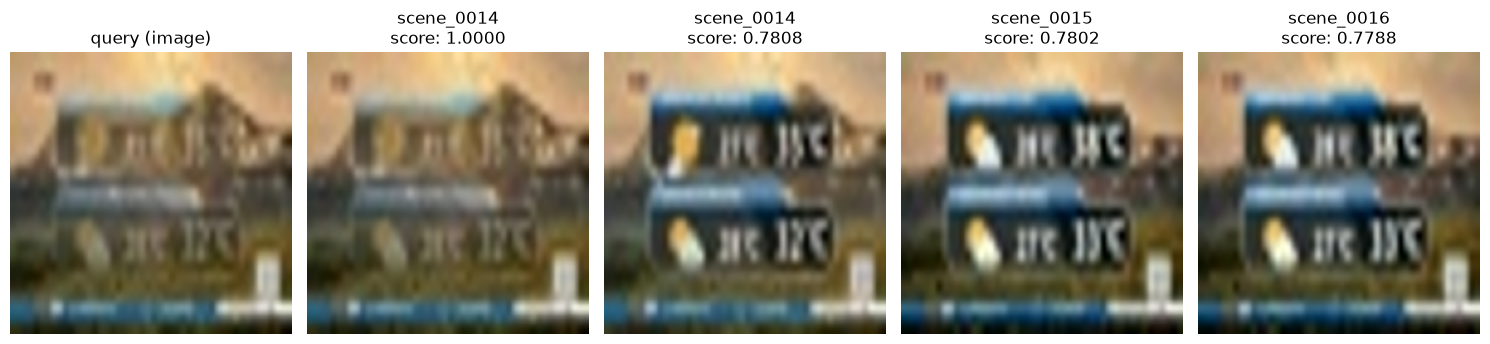

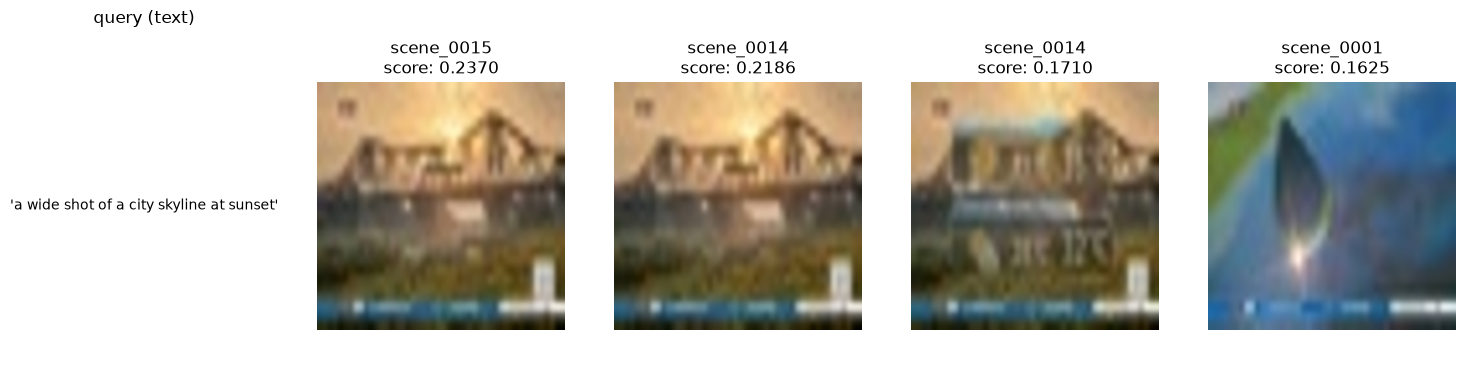

=== Threshold-based Keyframes Search ===


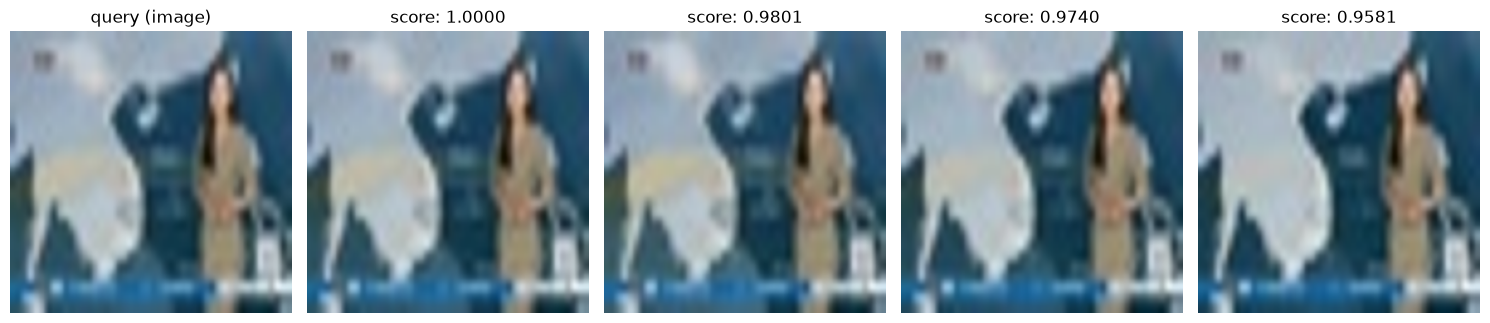

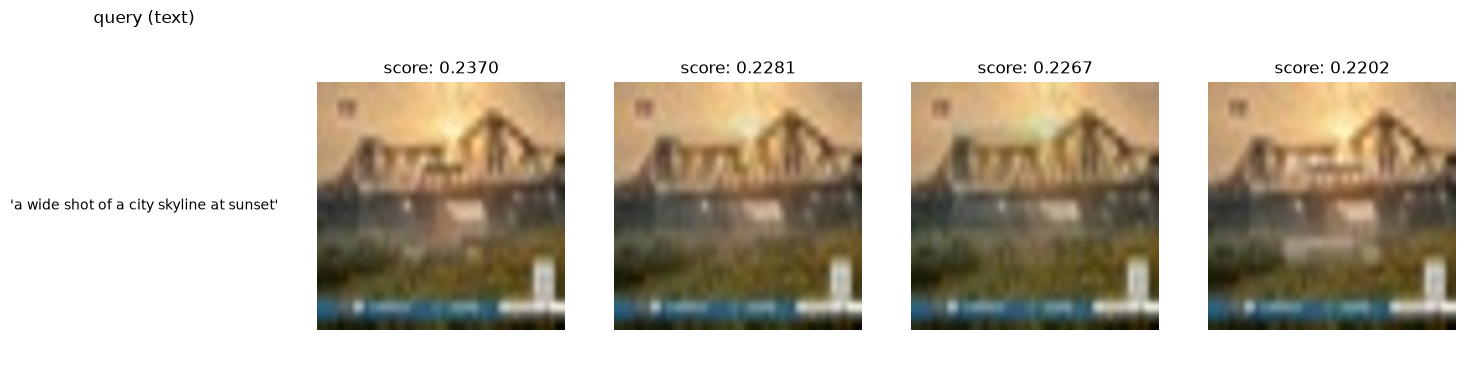

In [ ]:
import random

# 1. Test cho Scene-based Index
print("=== Scene-based Keyframes Search ===")
q_example = random.choice(img_paths)
top_idx, top_scores = query_by_image(q_example, topk=4)
show_results(top_idx, top_scores, query_img=q_example)

q_text = "a wide shot of a city skyline at sunset"
top_idx, top_scores = query_by_text(q_text, topk=4)
show_results(top_idx, top_scores, query_text=q_text)

# 2. Test cho Threshold-based Index
print("=== Threshold-based Keyframes Search ===")
q_example_thres = random.choice(threshold_img_paths)
top_idx, top_scores = threshold_query_by_image(q_example_thres, top_k=4)
threshold_show_results(top_idx, top_scores, query_img=q_example_thres)

top_idx, top_scores = threshold_query_by_text(q_text, top_k=4)
threshold_show_results(top_idx, top_scores, query_text=q_text)

## 4. Adaptive Temporal Search va Reranking

Day la thuat toan Adaptive Temporal Search giup tim kiem cac phan doan tuan tu co tinh chat thoi gian dua tren y tuong tu paper CVPRW 2025 cua GenAI4E:

```python
def adaptive_temporal_search(video_keyframes, query1_emb, query2_emb, tolerance_threshold=3):
    best_score = 0
    best_pair = None
    for i, kf_i in enumerate(video_keyframes):
        sim1 = cosine_similarity(kf_i.emb, query1_emb)
        tolerance = 0
        best_sim2 = 0
        best_j = None
        for j in range(i + 1, len(video_keyframes)):
            sim2 = cosine_similarity(video_keyframes[j].emb, query2_emb)
            if sim2 > best_sim2:
                best_sim2 = sim2
                best_j = j
                tolerance = 0
            else:
                tolerance += 1
            if tolerance >= tolerance_threshold:
                break
        if best_j is not None:
            score = sim1 + best_sim2
            if score > best_score:
                best_score = score
                best_pair = (i, best_j)
    return best_pair, best_score
```